---

## Pit Window Forecasting, Code Notebook: Data, Methodology & Expected Outcomes

This notebook is my walk-through of how I built the pit-window forecasting pipeline, what data it uses, why I made the modeling choices I did, and what I expected to learn from it.

---

### Data Description

This notebook works off lap-level race data pulled from the **FastF1 API** across the **2020–2024 seasons**. I split the data into two jobs:

- **Degradation training years (2020–2021):** I use these only to fit the tire degradation curves. I keep them separate on purpose so the pit-window model never sees degradation features that were trained on the same seasons it is being judged on.
- **Label years (2022–2024):** I use these to build the forward-looking pit-window labels and train the gradient boosted regressor. Then I keep 2024 as the temporal holdout test set.

The notebook covers **27 circuits** with explicit pit-loss profiles, from 20.8s at the Austrian Grand Prix up to 24.5s at the Mexican Grand Prix. So I am trying to keep the circuit-to-circuit pit-lane differences realistic instead of pretending every stop costs the same amount of time.

**Data filtering applied:**
- Laps shorter than 60s or longer than 200s are dropped. This mostly catches in-laps, out-laps, red-flag laps, and other timing outliers.
- Safety Car, Virtual Safety Car, and yellow-flag laps are excluded from degradation fitting using composite `TrackStatus` codes (`{'2','4','5','6','7'}`).
- The opening lap and the final 15% of the race are excluded from label construction, because pit stops there are usually not very informative from a strategy-learning perspective.
- Pit entry and exit laps are excluded from driver observations, because the car is not really in a normal "decide whether to pit" state on those laps.


In [1]:
import fastf1
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path as _P
_ROOT = _P.cwd() if _P.cwd().name != 'notebooks' else _P.cwd().parent
_CACHE = _ROOT / 'f1-cache'
_CACHE.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(_CACHE))

# ─────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────

FUEL_BURN_RATE  = 1.8    # kg per lap
FUEL_LAP_EFFECT = 0.035  # seconds per kg of fuel
CLEAN_AIR_BUFFER = 3.0   # seconds of clear air required post-pit
FORECAST_HORIZON = 20    # laps forward to scan for window opening

CIRCUIT_PROFILES = {
    'Bahrain Grand Prix':        {'pit_loss': 21.5},
    'Saudi Arabian Grand Prix':  {'pit_loss': 24.1},
    'Australian Grand Prix':     {'pit_loss': 23.8},
    'Italian Grand Prix':        {'pit_loss': 21.1},
    'British Grand Prix':        {'pit_loss': 22.4},
    'Hungarian Grand Prix':      {'pit_loss': 21.8},
    'Belgian Grand Prix':        {'pit_loss': 24.0},
    'Spanish Grand Prix':        {'pit_loss': 22.0},
    'Azerbaijan Grand Prix':     {'pit_loss': 23.5},
    'Austrian Grand Prix':       {'pit_loss': 20.8},
    'Dutch Grand Prix':          {'pit_loss': 23.0},
    'United States Grand Prix':  {'pit_loss': 23.2},
    'Mexico City Grand Prix':    {'pit_loss': 24.5},
    'São Paulo Grand Prix':      {'pit_loss': 23.8},
    'Singapore Grand Prix':      {'pit_loss': 23.1},
    'Japanese Grand Prix':       {'pit_loss': 22.6},
    'Abu Dhabi Grand Prix':      {'pit_loss': 23.0},
    'Emilia Romagna Grand Prix': {'pit_loss': 22.0},
    'Monaco Grand Prix':         {'pit_loss': 22.0},
    'French Grand Prix':         {'pit_loss': 22.5},
    'Styrian Grand Prix':        {'pit_loss': 20.8},
    '70th Anniversary Grand Prix': {'pit_loss': 22.4},
    'Eifel Grand Prix':          {'pit_loss': 22.0},
    'Turkish Grand Prix':        {'pit_loss': 23.0},
    'Miami Grand Prix':          {'pit_loss': 23.3},
    'Las Vegas Grand Prix':      {'pit_loss': 24.0},
    'Qatar Grand Prix':          {'pit_loss': 23.5},
    'Canadian Grand Prix':       {'pit_loss': 22.8},
}


# ─────────────────────────────────────────────
# Track status filter
# ─────────────────────────────────────────────

def is_clean_lap(status: str) -> bool:
    """
    Returns True only for pure green flag laps.
    TrackStatus is a composite string — '124' means
    yellow + safety car active simultaneously.
    Any non-green code disqualifies the lap.
    """
    if pd.isna(status):
        return False
    return not any(c in {'2', '4', '5', '6', '7'} for c in str(status))


# ─────────────────────────────────────────────
# Gap computation
# ─────────────────────────────────────────────

def compute_inter_car_gaps(laps: pd.DataFrame) -> pd.DataFrame:
    """
    Compute gap to car directly ahead and directly behind
    for every driver on every lap, using the session Time
    column (elapsed seconds when each car crosses the line).

    gap = Time[car_behind] - Time[car_ahead]

    Cars are grouped by (Circuit, Year, LapNumber) and
    sorted by Position. The gap between adjacent positions
    is the difference in their crossing times.
    """
    laps = laps.copy()
    laps['TimeSeconds'] = laps['Time'].dt.total_seconds()
    gap_records = []

    for (circuit, year, lap_num), group in laps.groupby(
        ['Circuit', 'Year', 'LapNumber']
    ):
        group = group.dropna(subset=['Position', 'TimeSeconds'])
        group = group.sort_values('Position')

        times   = group['TimeSeconds'].values
        drivers = group['Driver'].values

        for i in range(len(drivers)):
            gap_ahead  = times[i] - times[i-1] if i > 0 else np.nan
            gap_behind = times[i+1] - times[i] if i < len(times)-1 else np.nan

            gap_records.append({
                'Driver':    drivers[i],
                'LapNumber': lap_num,
                'Circuit':   circuit,
                'Year':      year,
                'GapAhead':  round(gap_ahead,  3) if not np.isnan(gap_ahead)  else np.nan,
                'GapBehind': round(gap_behind, 3) if not np.isnan(gap_behind) else np.nan,
            })

    return pd.DataFrame(gap_records)


# ─────────────────────────────────────────────
# Data loader
# ─────────────────────────────────────────────

def load_race_laps(
    year: int,
    round_number: int
) -> tuple[pd.DataFrame, pd.DataFrame] | tuple[None, None]:
    """
    Load a single race. Returns two dataframes:

    clean_laps — SC/VSC/yellow laps removed.
                 Used for degradation model fitting only.

    all_laps   — base quality filter only, pit entry laps
                 retained. Used for gap computation and
                 forward-looking label construction.
    """
    try:
        session = fastf1.get_session(year, round_number, 'R')
        session.load(telemetry=False, weather=False, messages=False)
        laps = session.laps.copy()

        laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
        laps['Circuit']        = session.event['EventName']
        laps['Year']           = year

        base = laps[
            laps['LapTime'].notna() &
            laps['Compound'].notna() &
            laps['TyreLife'].notna() &
            laps['LapTimeSeconds'].notna() &
            (laps['LapNumber'] > 1) &
            (laps['LapTimeSeconds'] > 60) &
            (laps['LapTimeSeconds'] < 200)
        ].copy()

        all_laps   = base.copy()
        clean_laps = base[base['TrackStatus'].apply(is_clean_lap)].copy()

        print(f"  {year} R{round_number} {session.event['EventName']}: "
              f"{len(clean_laps)} clean / {len(all_laps)} total laps")
        return clean_laps, all_laps

    except Exception as e:
        print(f"  Skipped {year} R{round_number}: {e}")
        return None, None


def get_rounds_for_circuits(year: int, target_circuits: list[str]) -> list[int]:
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    return [
        int(event['RoundNumber'])
        for _, event in schedule.iterrows()
        if event['EventName'] in target_circuits
    ]


def load_dataset(years: list[int]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load all races from the given years that appear in
    CIRCUIT_PROFILES. Returns (clean_laps, all_laps).
    """
    clean_frames, all_frames = [], []
    target_circuits = list(CIRCUIT_PROFILES.keys())

    for year in years:
        rounds = get_rounds_for_circuits(year, target_circuits)
        if not rounds:
            print(f"  No matching circuits for {year}")
            continue
        print(f"\n  {year}: rounds {rounds}")
        for rnd in rounds:
            clean, all_ = load_race_laps(year, rnd)
            if clean is not None and len(clean) > 0:
                clean_frames.append(clean)
            if all_ is not None and len(all_) > 0:
                all_frames.append(all_)

    if not clean_frames and not all_frames:
        raise ValueError("No data loaded.")

    clean_df = pd.concat(clean_frames, ignore_index=True) if clean_frames else pd.DataFrame()
    all_df   = pd.concat(all_frames,   ignore_index=True) if all_frames   else pd.DataFrame()
    return clean_df, all_df


# ─────────────────────────────────────────────
# Pipeline check
# ─────────────────────────────────────────────

def check_pipeline(year: int = 2023, round_number: int = 2) -> None:
    """
    Load one race and verify the pipeline is working.
    Checks lap counts, gap distribution, and pit stop count.
    """
    clean, all_laps = load_race_laps(year, round_number)
    if all_laps is None:
        print("FAILED — could not load session")
        return

    gaps = compute_inter_car_gaps(all_laps)
    valid_gaps = gaps['GapAhead'].dropna()
    valid_gaps = valid_gaps[(valid_gaps > 0) & (valid_gaps < 120)]

    pit_stops = all_laps['PitOutTime'].notna().sum()
    circuit   = all_laps['Circuit'].iloc[0]

    print(f"\nPipeline check — {year} R{round_number} {circuit}")
    print(f"  Clean laps    : {len(clean)}")
    print(f"  Total laps    : {len(all_laps)}")
    print(f"  Pit stops     : {pit_stops}")
    print(f"  Gap median    : {valid_gaps.median():.2f}s")
    print(f"  Gap p99       : {valid_gaps.quantile(0.99):.2f}s")
    print(f"  Gap % > 25s   : {(valid_gaps > 25).mean():.1%}")
    print(f"  Circuit in profiles: {circuit in CIRCUIT_PROFILES}")
    print("\nPipeline OK" if circuit in CIRCUIT_PROFILES else "\nWARNING: circuit not in profiles")


if __name__ == '__main__':
    check_pipeline(2023, 2)


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']


  2023 R2 Saudi Arabian Grand Prix: 845 clean / 904 total laps

Pipeline check — 2023 R2 Saudi Arabian Grand Prix
  Clean laps    : 845
  Total laps    : 904
  Pit stops     : 17
  Gap median    : 2.08s
  Gap p99       : 32.33s
  Gap % > 25s   : 1.6%
  Circuit in profiles: True

Pipeline OK


In [2]:
# ─────────────────────────────────────────────
# Phase 2 — Context classification
# ─────────────────────────────────────────────

def get_racing_gaps(
    lap_slice: pd.DataFrame,
    driver: str,
) -> tuple[float, float]:
    """
    Returns (gap_ahead, gap_behind) to the nearest car on the
    SAME LAP as this driver — excluding lapping leaders or
    cars being lapped.

    FastF1 assigns each car its own LapNumber based on how many
    laps it has personally completed. A lapped car will have a
    lower LapNumber than the leader at the same point in real
    time. Filtering by driver_lap_num ensures we only measure
    gaps to cars that are actually racing this driver.
    """
    driver_row = lap_slice[lap_slice['Driver'] == driver]
    if len(driver_row) == 0:
        return np.nan, np.nan

    driver_lap_num = driver_row.iloc[0]['LapNumber']
    driver_pos     = driver_row.iloc[0]['Position']

    # Only cars on the same lap count
    same_lap = lap_slice[
        lap_slice['LapNumber'] == driver_lap_num
    ].sort_values('Position')

    # Gap ahead — nearest same-lap car with lower position number
    cars_ahead = same_lap[same_lap['Position'] < driver_pos].sort_values(
        'Position', ascending=False
    )
    gap_ahead = np.nan
    if len(cars_ahead) > 0:
        # GapBehind of the car directly ahead = gap between them and driver
        ahead_pos = cars_ahead.iloc[0]['Position']
        ahead_row = same_lap[same_lap['Position'] == ahead_pos]
        if len(ahead_row) > 0:
            gap_ahead = ahead_row.iloc[0].get('GapBehind', np.nan)

    # Gap behind — GapBehind of the driver itself
    driver_same_lap = same_lap[same_lap['Driver'] == driver]
    gap_behind = np.nan
    if len(driver_same_lap) > 0:
        gap_behind = driver_same_lap.iloc[0].get('GapBehind', np.nan)

    return (
        round(float(gap_ahead),  3) if not pd.isna(gap_ahead)  else np.nan,
        round(float(gap_behind), 3) if not pd.isna(gap_behind) else np.nan,
    )


def classify_context(
    gap_ahead: float,
    gap_behind: float,
) -> str:
    """
    Describes the gap state only — makes no strategic implication.
    The prediction model learns circuit-specific strategy from
    the data, not from these labels.

    tight_ahead   — car ahead is a racing reference
    tight_behind  — car behind is a racing reference  
    tight_both    — racing references both sides
    free          — no immediate racing references
    """
    if pd.isna(gap_ahead) or pd.isna(gap_behind):
        return 'unknown'

    tight_ahead  = gap_ahead  < 5.0
    tight_behind = gap_behind < 5.0

    if tight_ahead and tight_behind:
        return 'tight_both'
    if tight_ahead:
        return 'tight_ahead'
    if tight_behind:
        return 'tight_behind'
    return 'free'
    
def find_threat_gap(
    lap_slice: pd.DataFrame,
    laps: pd.DataFrame,
    driver: str,
    driver_pos: float,
    driver_lap_num: float,
    lap_number: float,
    circuit: str,
    year: int,
    context: str,
    pit_window_laps: int = 3,
) -> tuple[float, str]:
    """
    Returns the gap to the first non-pitting car behind.

    This is the ONLY metric that determines whether a pit
    window is open. The car behind that stays out is what
    closes the window — they will pass the pitting driver
    during the stationary time and determine the rejoin gap.

    A window is open when:
        threat_gap > pit_loss + clean_air_buffer

    Context is recorded as a feature for the prediction model
    but does NOT change the scan direction. Whether a driver
    is in an undercut battle or running free, the window
    calculation is the same physical question.
    """
    def pits_soon(candidate_driver: str) -> bool:
        return len(laps[
            (laps['Driver']    == candidate_driver) &
            (laps['LapNumber'].between(lap_number, lap_number + pit_window_laps)) &
            (laps['Circuit']   == circuit) &
            (laps['Year']      == year) &
            (laps['PitOutTime'].notna())
        ]) > 0

    # Same-lap cars only — exclude lapping leaders
    same_lap = lap_slice[
        lap_slice['LapNumber'] == driver_lap_num
    ].sort_values('Position').reset_index(drop=True)

    driver_idx_list = same_lap[same_lap['Driver'] == driver].index.tolist()
    if not driver_idx_list:
        return np.nan, 'no_data'
    driver_idx = driver_idx_list[0]

    # Always scan behind — accumulate gap until first non-pitting car
    cumulative = 0.0
    for i in range(driver_idx, len(same_lap) - 1):
        gb = same_lap.iloc[i].get('GapBehind', np.nan)
        if pd.isna(gb):
            continue
        cumulative += gb
        candidate = same_lap.iloc[i + 1]['Driver']
        if not pits_soon(candidate):
            return round(cumulative, 3), f"behind:{candidate}"

    # All cars behind are pitting — window is effectively open
    return round(cumulative, 3) if cumulative > 0 else np.nan, 'behind:all_pitting'
    
# ─────────────────────────────────────────────
# Phase 2 check
# ─────────────────────────────────────────────

def check_context_classifier(year: int = 2023, round_number: int = 2) -> None:
    """
    Load one race and verify context classification and
    threat gap computation are producing sensible outputs.
    """
    _, all_laps = load_race_laps(year, round_number)
    if all_laps is None:
        return

    gaps_df = compute_inter_car_gaps(all_laps)
    all_laps = all_laps.merge(
        gaps_df[['Driver', 'LapNumber', 'Circuit', 'Year',
                 'GapAhead', 'GapBehind']],
        on=['Driver', 'LapNumber', 'Circuit', 'Year'],
        how='left'
    )

    circuit = all_laps['Circuit'].iloc[0]
    sample_lap = int(all_laps['LapNumber'].median())

    lap_slice = all_laps[
        all_laps['LapNumber'] == sample_lap
    ].sort_values('Position')

    print(f"\nContext check — {year} R{round_number} {circuit} lap {sample_lap}")
    print(f"  {'Driver':<6} {'Pos':>4} {'GapAhead':>10} {'GapBehind':>10} {'Context':<12} {'ThreatGap':>10} {'Threat'}")
    print(f"  {'-'*75}")

    for _, row in lap_slice.iterrows():
        driver = row['Driver']
        pos    = row.get('Position', np.nan)

        if pd.isna(pos):
            continue

        driver_lap_num = row['LapNumber']
        ga, gb = get_racing_gaps(lap_slice, driver)
        if pd.isna(ga) or pd.isna(gb):
            continue

        ctx = classify_context(ga, gb)

        threat_gap, threat_desc = find_threat_gap(
            lap_slice   = lap_slice,
            laps        = all_laps,
            driver      = driver,
            driver_pos  = pos,
            driver_lap_num = driver_lap_num,
            lap_number  = sample_lap,
            circuit     = circuit,
            year        = year,
            context     = ctx,
        )

        print(f"  {driver:<6} {int(pos):>4} {ga:>10.2f} {gb:>10.2f} "
              f"{ctx:<12} "
              f"{threat_gap:>10.2f} {threat_desc}")


if __name__ == '__main__':
    check_pipeline(2023, 2)
    check_context_classifier(2023, 2)


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data

  2023 R2 Saudi Arabian Grand Prix: 845 clean / 904 total laps

Pipeline check — 2023 R2 Saudi Arabian Grand Prix
  Clean laps    : 845
  Total laps    : 904
  Pit stops     : 17
  Gap median    : 2.08s
  Gap p99       : 32.33s
  Gap % > 25s   : 1.6%
  Circuit in profiles: True

Pipeline OK


core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']


  2023 R2 Saudi Arabian Grand Prix: 845 clean / 904 total laps

Context check — 2023 R2 Saudi Arabian Grand Prix lap 25
  Driver  Pos   GapAhead  GapBehind Context       ThreatGap Threat
  ---------------------------------------------------------------------------
  VER       2       5.48       0.88 tight_behind       0.88 behind:ALO
  ALO       3       0.88       1.70 tight_both         1.70 behind:RUS
  RUS       4       1.70       1.13 tight_both         1.13 behind:HAM
  HAM       5       1.13       1.71 tight_both         1.71 behind:SAI
  SAI       6       1.71       1.27 tight_both         1.27 behind:LEC
  LEC       7       1.27       2.27 tight_both         2.27 behind:OCO
  OCO       8       2.27       1.90 tight_both         1.90 behind:GAS
  GAS       9       1.90       1.25 tight_both         1.25 behind:TSU
  TSU      10       1.25       0.36 tight_both         0.36 behind:MAG
  MAG      11       0.36       0.28 tight_both         0.28 behind:HUL
  HUL      12       0.28 

In [3]:
# ─────────────────────────────────────────────
# Phase 3 — Degradation model
# ─────────────────────────────────────────────

def fuel_correction(lap_number: float) -> float:
    """
    Lap time reduction due to fuel burn by this lap.
    Lap 1 baseline = 0s correction.
    Each subsequent lap the car is lighter by FUEL_BURN_RATE kg,
    gaining FUEL_LAP_EFFECT seconds of pace.

    Example: lap 30 → 29 laps burned → 29 × 1.8 × 0.035 = 1.827s
    faster than lap 1 due to fuel alone. Without this correction
    early laps look artificially degraded because the car is
    heavier, not because the tyre is worn.
    """
    return (lap_number - 1) * FUEL_BURN_RATE * FUEL_LAP_EFFECT


def compute_crossover_lap(
    coeffs_a: np.ndarray,
    coeffs_b: np.ndarray,
    max_laps: int = 60
) -> int | None:
    """
    Find the stint lap at which compound B cumulative time
    becomes lower than compound A cumulative time.

    This is the strategic crossover point — beyond this lap
    a driver on compound B has spent less total time than
    one who started on compound A, even though B is slower
    per lap early in the stint.
    """
    poly_a = np.poly1d(coeffs_a)
    poly_b = np.poly1d(coeffs_b)
    for lap in range(1, max_laps):
        laps_arr = np.arange(1, lap + 1)
        if np.sum(poly_b(laps_arr)) < np.sum(poly_a(laps_arr)):
            return lap
    return None


def fit_degradation_model(
    clean_laps: pd.DataFrame
) -> dict[str, dict[str, np.ndarray]]:
    """
    Fit a quadratic degradation curve per compound per circuit
    on fuel-corrected lap times.

    Returns nested dict:
        coeffs[circuit][compound] = np.ndarray of [a2, a1, a0]

    These coefficients are used at prediction time to estimate
    how much slower a tyre will be at a given age, which feeds
    into the crossover point calculation and stint length targets.
    """
    coeffs: dict[str, dict[str, np.ndarray]] = {}

    for circuit in clean_laps['Circuit'].unique():
        profile = CIRCUIT_PROFILES.get(circuit)
        if profile is None:
            continue

        coeffs[circuit] = {}
        circuit_laps = clean_laps[clean_laps['Circuit'] == circuit]

        for compound in ['SOFT', 'MEDIUM', 'HARD']:
            stint_laps = circuit_laps[
                (circuit_laps['Compound'] == compound) &
                (circuit_laps['TyreLife'] > 1)
            ].copy()

            if len(stint_laps) < 15:
                continue

            # Fuel-corrected pace delta from each driver's baseline
            stint_laps['FuelCorr']  = stint_laps['LapNumber'].apply(fuel_correction)
            stint_laps['CorrTime']  = stint_laps['LapTimeSeconds'] - stint_laps['FuelCorr']
            stint_laps['BasePace']  = stint_laps.groupby('DriverNumber')['CorrTime'].transform('min')
            stint_laps['PaceDelta'] = stint_laps['CorrTime'] - stint_laps['BasePace']

            # Remove outliers — delta > 5s is a slow lap, not degradation
            stint_laps = stint_laps[stint_laps['PaceDelta'].between(0, 5)]
            if len(stint_laps) < 10:
                continue

            try:
                c = np.polyfit(
                    stint_laps['TyreLife'].values.astype(float),
                    stint_laps['PaceDelta'].values,
                    deg=2
                )
                coeffs[circuit][compound] = c
            except np.linalg.LinAlgError:
                continue

    return coeffs


def evaluate_degradation_model(
    train_coeffs: dict[str, dict[str, np.ndarray]],
    test_laps: pd.DataFrame
) -> pd.DataFrame:
    """
    Measure RMSE and MAE of the fitted degradation curves
    against held-out test laps.

    Also computes compound crossover laps per circuit —
    the stint length beyond which a harder compound would
    have been faster in total.
    """
    results = []

    for circuit, compound_coeffs in train_coeffs.items():
        circuit_test = test_laps[test_laps['Circuit'] == circuit]

        for compound, coeffs in compound_coeffs.items():
            test = circuit_test[
                (circuit_test['Compound'] == compound) &
                (circuit_test['TyreLife'] > 1)
            ].copy()

            if len(test) < 5:
                continue

            test['FuelCorr']  = test['LapNumber'].apply(fuel_correction)
            test['CorrTime']  = test['LapTimeSeconds'] - test['FuelCorr']
            test['BasePace']  = test.groupby('DriverNumber')['CorrTime'].transform('min')
            test['PaceDelta'] = test['CorrTime'] - test['BasePace']
            test = test[test['PaceDelta'].between(0, 5)]

            if len(test) < 5:
                continue

            poly   = np.poly1d(coeffs)
            y_pred = poly(test['TyreLife'].values.astype(float))
            y_test = test['PaceDelta'].values

            rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
            mae  = float(mean_absolute_error(y_test, y_pred))

            results.append({
                'circuit':  circuit,
                'compound': compound,
                'rmse_s':   round(rmse, 4),
                'mae_s':    round(mae, 4),
                'n_test':   len(test),
            })

    df = pd.DataFrame(results)

    # Crossover points
    print("\n  Crossover laps (fuel-corrected):")
    for circuit, compound_coeffs in train_coeffs.items():
        pairs = [
            ('SOFT',   'MEDIUM'),
            ('SOFT',   'HARD'),
            ('MEDIUM', 'HARD'),
        ]
        for c_a, c_b in pairs:
            if c_a in compound_coeffs and c_b in compound_coeffs:
                lap = compute_crossover_lap(
                    compound_coeffs[c_a],
                    compound_coeffs[c_b]
                )
                print(f"    {circuit:<30} {c_a} → {c_b}: lap {lap}")

    return df


# ─────────────────────────────────────────────
# Phase 3 check
# ─────────────────────────────────────────────

def check_degradation_model(
    train_years: list[int] = [2020, 2021],
    test_years:  list[int] = [2023, 2024]
) -> None:
    print("\nLoading train data...")
    train_clean, _ = load_dataset(train_years)

    print("\nLoading test data...")
    test_clean, _  = load_dataset(test_years)

    print("\nFitting degradation model...")
    coeffs = fit_degradation_model(train_clean)
    print(f"  Fitted {sum(len(v) for v in coeffs.values())} compound curves "
          f"across {len(coeffs)} circuits")

    print("\nEvaluating on test data...")
    results = evaluate_degradation_model(coeffs, test_clean)

    if len(results) > 0:
        print(f"\n{results.to_string(index=False)}")
        print(f"\n  Mean RMSE: {results['rmse_s'].mean():.4f}s")
        print(f"  Mean MAE : {results['mae_s'].mean():.4f}s")
    else:
        print("  No test results — check circuit overlap between train and test years")


if __name__ == '__main__':
    check_pipeline(2023, 2)
    check_context_classifier(2023, 2)
    check_degradation_model()


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data

  2023 R2 Saudi Arabian Grand Prix: 845 clean / 904 total laps

Pipeline check — 2023 R2 Saudi Arabian Grand Prix
  Clean laps    : 845
  Total laps    : 904
  Pit stops     : 17
  Gap median    : 2.08s
  Gap p99       : 32.33s
  Gap % > 25s   : 1.6%
  Circuit in profiles: True

Pipeline OK


core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  2023 R2 Saudi Arabian Grand Prix: 845 clean / 904 total laps

Context check — 2023 R2 Saudi Arabian Grand Prix lap 25
  Driver  Pos   GapAhead  GapBehind Context       ThreatGap Threat
  ---------------------------------------------------------------------------
  VER       2       5.48       0.88 tight_behind       0.88 behind:ALO
  ALO       3       0.88       1.70 tight_both         1.70 behind:RUS
  RUS       4       1.70       1.13 tight_both         1.13 behind:HAM
  HAM       5       1.13       1.71 tight_both         1.71 behind:SAI
  SAI       6       1.71       1.27 tight_both         1.27 behind:LEC
  LEC       7       1.27       2.27 tight_both         2.27 behind:OCO
  OCO       8       2.27       1.90 tight_both         1.90 behind:GAS
  GAS       9       1.90       1.25 tight_both         1.25 behind:TSU
  TSU      10       1.25       0.36 tight_both         0.36 behind:MAG
  MAG      11       0.36       0.28 tight_both         0.28 behind:HUL
  HUL      12       0.28 

core        WARNING 	Driver  8: Lap timing integrity check failed for 1 lap(s)
core           INFO 	Finished loading data for 20 drivers: ['77', '16', '4', '44', '55', '11', '10', '31', '99', '5', '6', '26', '23', '7', '63', '8', '20', '18', '3', '33']
core           INFO 	Loading data for Styrian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

  2024 R22 Las Vegas Grand Prix: 918 clean / 918 total laps


core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  2024 R23 Qatar Grand Prix: 697 clean / 905 total laps


core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


  2024 R24 Abu Dhabi Grand Prix: 933 clean / 1014 total laps

Fitting degradation model...
  Fitted 60 compound curves across 22 circuits

Evaluating on test data...

  Crossover laps (fuel-corrected):
    Austrian Grand Prix            SOFT → MEDIUM: lap None
    Austrian Grand Prix            SOFT → HARD: lap 47
    Austrian Grand Prix            MEDIUM → HARD: lap 1
    Styrian Grand Prix             SOFT → MEDIUM: lap None
    Styrian Grand Prix             SOFT → HARD: lap 1
    Styrian Grand Prix             MEDIUM → HARD: lap 1
    Hungarian Grand Prix           SOFT → MEDIUM: lap 30
    Hungarian Grand Prix           SOFT → HARD: lap 29
    Hungarian Grand Prix           MEDIUM → HARD: lap 1
    British Grand Prix             SOFT → MEDIUM: lap None
    British Grand Prix             SOFT → HARD: lap None
    British Grand Prix             MEDIUM → HARD: lap 56
    70th Anniversary Grand Prix    MEDIUM → HARD: lap None
    Spanish Grand Prix             SOFT → MEDIUM: lap 53
  

In [4]:
# ─────────────────────────────────────────────
# Phase 4 — Forward-looking label construction
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# Pace-adjusted window check
# ─────────────────────────────────────────────

def is_window_viable(
    threat_gap: float,
    pit_loss: float,
    own_pace: float,
    threat_pace: float,
    clean_air_buffer: float = CLEAN_AIR_BUFFER,
) -> bool:
    """
    Dynamic window viability check accounting for relative pace.

    A Red Bull 8s behind a Williams closes that gap in very
    few laps. A Williams 8s behind a Red Bull never closes it.
    The static threshold treats both identically — this does not.

    closing_rate = own_pace - threat_pace
      positive → threat car is faster, gap is closing
      negative → threat car is slower, gap is growing
      zero     → same pace, static gap

    Window is open if the threat car cannot close the gap
    during the pit stop plus the clean air buffer period.
    """
    closing_rate = own_pace - threat_pace

    if closing_rate <= 0:
        # Threat car same pace or slower — gap not closing
        # Use static check
        return threat_gap > pit_loss + clean_air_buffer

    # Threat car is faster — check if they close the gap
    # before driver rejoins with clean air
    # Time for threat to cover threat_gap at closing_rate laps/s
    laps_until_caught = threat_gap / closing_rate
    laps_lost         = pit_loss / own_pace

    return laps_until_caught > laps_lost + (clean_air_buffer / own_pace)


def get_recent_pace(
    laps: pd.DataFrame,
    driver: str,
    lap_number: float,
    circuit: str,
    year: int,
    window: int = 5,
) -> float:
    """
    Average lap time over the last N clean (green flag) laps.
    Returns nan if fewer than 2 clean laps available.
    """
    recent = laps[
        (laps['Driver']      == driver) &
        (laps['LapNumber'].between(lap_number - window, lap_number - 1)) &
        (laps['Circuit']     == circuit) &
        (laps['Year']        == year) &
        (laps['TrackStatus'] == '1') &
        (laps['LapTimeSeconds'].notna())
    ]['LapTimeSeconds']

    return float(recent.mean()) if len(recent) >= 2 else np.nan

def construct_forward_labels(
    laps: pd.DataFrame,
    train_coeffs: dict[str, dict[str, np.ndarray]],
    forecast_horizon: int = FORECAST_HORIZON,
    clean_air_buffer: float = CLEAN_AIR_BUFFER,
    min_lap: int = 5,
    max_lap_fraction: float = 0.85,
) -> pd.DataFrame:

    gaps_df = compute_inter_car_gaps(laps)
    laps = laps.merge(
        gaps_df[['Driver', 'LapNumber', 'Circuit', 'Year',
                 'GapAhead', 'GapBehind']],
        on=['Driver', 'LapNumber', 'Circuit', 'Year'],
        how='left'
    )

    total_laps_map = (
        laps.groupby(['Circuit', 'Year'])['LapNumber']
        .max()
        .to_dict()
    )

    # ── Precompute circuit/year level stats ───────────────
    # Done once here rather than inside the driver loop
    # so we are not recomputing for every driver every lap
    circuit_stats: dict[tuple, dict] = {}
    for (circuit, year), race_laps in laps.groupby(['Circuit', 'Year']):
        profile = CIRCUIT_PROFILES.get(circuit)
        if profile is None:
            continue

        pit_loss = profile['pit_loss']

        median_gap = float(
            race_laps['GapBehind'].dropna().median()
        )

        median_lap_time = float(
            race_laps[race_laps['LapTimeSeconds'] > 60]['LapTimeSeconds'].median()
        )

        pit_loss_fraction = (
            pit_loss / median_lap_time
            if median_lap_time > 0 else np.nan
        )
        # ── VSC/SC rates for this circuit ─────────────────
        sc_laps = race_laps['TrackStatus'].apply(
            lambda s: any(c in {'4', '5'} for c in str(s))
        ).sum()
        vsc_laps = race_laps['TrackStatus'].apply(
            lambda s: any(c in {'6', '7'} for c in str(s))
        ).sum()
        total_race_laps = len(race_laps)

        sc_rate  = round(sc_laps  / total_race_laps, 4) if total_race_laps > 0 else 0.0
        vsc_rate = round(vsc_laps / total_race_laps, 4) if total_race_laps > 0 else 0.0

        circuit_stats[(circuit, year)] = {
            'pit_loss':           pit_loss,
            'circuit_median_gap': round(median_gap, 3),
            'pit_loss_fraction':  round(pit_loss_fraction, 4),
            'sc_rate':            sc_rate,
            'vsc_rate':           vsc_rate,
        }
        
    records = []

    for (circuit, year, driver), driver_laps in laps.groupby(
        ['Circuit', 'Year', 'Driver']
    ):
        stats = circuit_stats.get((circuit, year))
        if stats is None:
            continue

        pit_loss          = stats['pit_loss']
        circuit_median_gap = stats['circuit_median_gap']
        pit_loss_fraction  = stats['pit_loss_fraction']
        sc_rate            = stats['sc_rate']       # ← add
        vsc_rate           = stats['vsc_rate']      # ← add
        threshold          = pit_loss + clean_air_buffer
        total              = total_laps_map.get((circuit, year), 999)

        driver_laps = driver_laps.sort_values('LapNumber').reset_index(drop=True)

        for i, row in driver_laps.iterrows():
            lap_num  = row['LapNumber']
            position = row.get('Position', np.nan)

            # Skip opening laps, closing laps, and pit lane laps
            if lap_num < min_lap:
                continue
            if lap_num > total * max_lap_fraction:
                continue
            if pd.notna(row.get('PitInTime')) or pd.notna(row.get('PitOutTime')):
                continue
            if pd.isna(position):
                continue

            # Current lap slice — all cars on this lap
            lap_slice = laps[
                (laps['LapNumber'] == lap_num) &
                (laps['Circuit']   == circuit) &
                (laps['Year']      == year)
            ].sort_values('Position')

            # Racing gaps — same-lap cars only
            ga, gb = get_racing_gaps(lap_slice, driver)
            if pd.isna(ga) or pd.isna(gb):
                continue

            context = classify_context(ga, gb)
            if context == 'unknown':
                continue

            driver_lap_num = row['LapNumber']

            # Current effective threat gap
            current_threat_gap, current_threat_desc = find_threat_gap(
                lap_slice      = lap_slice,
                laps           = laps,
                driver         = driver,
                driver_pos     = position,
                driver_lap_num = driver_lap_num,
                lap_number     = lap_num,
                circuit        = circuit,
                year           = year,
                context        = context,
            )

            if pd.isna(current_threat_gap):
                continue

            # ── Relative pace ─────────────────────────────────
            own_pace = get_recent_pace(
                laps, driver, lap_num, circuit, year
            )

            # Parse threat driver from description
            # format is 'behind:VER' or 'behind:all_pitting'
            threat_driver_name = (
                current_threat_desc.split(':')[1]
                if ':' in current_threat_desc and
                current_threat_desc.split(':')[1] != 'all_pitting'
                else None
            )

            threat_pace = (
                get_recent_pace(laps, threat_driver_name, lap_num, circuit, year)
                if threat_driver_name else np.nan
            )

            closing_rate = (
                round(own_pace - threat_pace, 4)
                if not pd.isna(own_pace) and not pd.isna(threat_pace)
                else 0.0
            )

            # ── Window viability ──────────────────────────────
            if not pd.isna(own_pace) and not pd.isna(threat_pace):
                gap_is_open_now = int(is_window_viable(
                    threat_gap       = current_threat_gap,
                    pit_loss         = pit_loss,
                    own_pace         = own_pace,
                    threat_pace      = threat_pace,
                    clean_air_buffer = clean_air_buffer,
                ))
            else:
                # Fallback to static check if pace unavailable
                gap_is_open_now = int(
                    current_threat_gap > pit_loss + clean_air_buffer
                )

            # ── Gap trend — last 3 laps ───────────────────────
            recent_gaps = []
            for past_offset in [3, 2, 1]:
                past_lap = lap_num - past_offset
                past_slice = laps[
                    (laps['LapNumber'] == past_lap) &
                    (laps['Circuit']   == circuit) &
                    (laps['Year']      == year)
                ].sort_values('Position')
                if len(past_slice) == 0:
                    continue
                past_ga, past_gb = get_racing_gaps(past_slice, driver)
                past_ctx = classify_context(
                    past_ga if not pd.isna(past_ga) else ga,
                    past_gb if not pd.isna(past_gb) else gb
                )
                past_threat, _ = find_threat_gap(
                    lap_slice      = past_slice,
                    laps           = laps,
                    driver         = driver,
                    driver_pos     = position,
                    driver_lap_num = past_lap,
                    lap_number     = past_lap,
                    circuit        = circuit,
                    year           = year,
                    context        = past_ctx,
                )
                if not pd.isna(past_threat):
                    recent_gaps.append(past_threat)

            gap_trend = 0.0
            if len(recent_gaps) >= 2:
                gap_trend = float(
                    np.polyfit(range(len(recent_gaps)), recent_gaps, 1)[0]
                )

            # ── Degradation delta at current tire age ─────────
            tire_age = int(row.get('TyreLife', 1))
            stint_number = int(row.get('Stint', 1))  
            compound = row.get('Compound', 'UNKNOWN')
            deg_delta = 0.0
            circuit_coeffs = train_coeffs.get(circuit, {})
            if compound in circuit_coeffs:
                poly      = np.poly1d(circuit_coeffs[compound])
                deg_delta = float(poly(tire_age))

            

            # ── Recent pit activity behind, known at this lap ─────
            cars_behind_pitting = len(laps[
                (laps['LapNumber'].between(lap_num - 3, lap_num)) &
                (laps['Circuit']   == circuit) &
                (laps['Year']      == year) &
                (laps['PitOutTime'].notna())
            ])

            # ── Forward scan: find when gap first opens ────────
            laps_until_open = None
            window_open_lap = None

            for offset in range(forecast_horizon + 1):
                future_lap = lap_num + offset

                future_slice = laps[
                    (laps['LapNumber'] == future_lap) &
                    (laps['Circuit']   == circuit) &
                    (laps['Year']      == year)
                ].sort_values('Position')

                future_driver_row = future_slice[future_slice['Driver'] == driver]
                if len(future_driver_row) == 0:
                    break

                future_pos = future_driver_row.iloc[0].get('Position', np.nan)
                if pd.isna(future_pos):
                    break

                future_ga, future_gb = get_racing_gaps(future_slice, driver)
                if pd.isna(future_ga) or pd.isna(future_gb):
                    continue

                future_ctx = classify_context(future_ga, future_gb)

                future_threat, future_threat_desc = find_threat_gap(
                    lap_slice      = future_slice,
                    laps           = laps,
                    driver         = driver,
                    driver_pos     = future_pos,
                    driver_lap_num = future_lap,
                    lap_number     = future_lap,
                    circuit        = circuit,
                    year           = year,
                    context        = future_ctx,
                )

                if pd.isna(future_threat):
                    continue

                # ── Use pace-adjusted check in forward scan ────
                # Extract future threat driver for pace lookup
                future_threat_driver = (
                    future_threat_desc.split(':')[1]
                    if ':' in future_threat_desc and
                    future_threat_desc.split(':')[1] != 'all_pitting'
                    else None
                )

                future_own_pace = get_recent_pace(
                    laps, driver, future_lap, circuit, year
                )
                future_threat_pace = (
                    get_recent_pace(laps, future_threat_driver, future_lap, circuit, year)
                    if future_threat_driver else np.nan
                )

                if not pd.isna(future_own_pace) and not pd.isna(future_threat_pace):
                    window_open = is_window_viable(
                        threat_gap       = future_threat,
                        pit_loss         = pit_loss,
                        own_pace         = future_own_pace,
                        threat_pace      = future_threat_pace,
                        clean_air_buffer = clean_air_buffer,
                    )
                else:
                    # Fallback to static check
                    window_open = future_threat > threshold

                if window_open:
                    laps_until_open = offset
                    window_open_lap = int(future_lap)
                    break

            records.append({
                # identifiers unchanged
                'year':               year,
                'circuit':            circuit,
                'driver':             driver,
                'lap':                int(lap_num),
                # features
                'compound':           compound,
                'tire_age':           tire_age,
                'stint_number': stint_number,
                'context':            context,            # now tight_ahead/tight_behind/tight_both/free
                'gap_ahead':          round(ga, 3),
                'gap_behind':         round(gb, 3),
                'threat_gap':         round(current_threat_gap, 3),
                'gap_trend':          round(gap_trend, 4),
                'deg_delta':          round(deg_delta, 4),
                'cars_behind_pitting': cars_behind_pitting,
                'pit_loss':           pit_loss,
                'pit_loss_fraction':  round(pit_loss_fraction, 4) if not pd.isna(pit_loss_fraction) else np.nan,
                'circuit_median_gap': round(circuit_median_gap, 3),
                # targets unchanged
                'gap_is_open_now':    gap_is_open_now,
                'laps_until_open':    laps_until_open,
                'window_open_lap':    window_open_lap,
                'opens_in_horizon':   int(laps_until_open is not None),
                'own_pace':       round(own_pace,    3) if not pd.isna(own_pace)    else np.nan,
                'threat_pace':    round(threat_pace, 3) if not pd.isna(threat_pace) else np.nan,
                'closing_rate':   closing_rate,
                'race_progress': round(lap_num / total, 4),
                'sc_rate':            sc_rate,
                'vsc_rate':           vsc_rate,
            })

    return pd.DataFrame(records)


# ─────────────────────────────────────────────
# Phase 4 check
# ─────────────────────────────────────────────
def compute_vsc_sc_rates(
    laps: pd.DataFrame,
) -> dict[str, float]:
    """
    Compute historical VSC and SC deployment rates per circuit
    from the laps dataframe.

    Rate = fraction of laps run under VSC or SC conditions.
    Used as a feature representing the probability of a safety
    car period occurring at this circuit, which affects whether
    a team should stretch a stint to take a cheaper pit stop.

    TrackStatus codes:
        4  = Safety Car
        5  = Red Flag
        6  = VSC deployed
        7  = VSC ending
    """
    rates = {}
    sc_codes  = {'4', '5'}
    vsc_codes = {'6', '7'}

    for circuit, circuit_laps in laps.groupby('Circuit'):
        total = len(circuit_laps)
        if total == 0:
            continue

        sc_laps = circuit_laps['TrackStatus'].apply(
            lambda s: any(c in sc_codes for c in str(s))
        ).sum()

        vsc_laps = circuit_laps['TrackStatus'].apply(
            lambda s: any(c in vsc_codes for c in str(s))
        ).sum()

        rates[circuit] = {
            'sc_rate':  round(sc_laps  / total, 4),
            'vsc_rate': round(vsc_laps / total, 4),
        }

    return rates
    
def check_forward_labels(
    year: int = 2023,
    round_number: int = 2,
    train_years: list[int] = [2020, 2021]
) -> None:
    """
    Run forward label construction on one race and verify
    the label distribution looks physically sensible.
    """
    print(f"\nLoading train data for deg model...")
    train_clean, _ = load_dataset(train_years)
    train_coeffs   = fit_degradation_model(train_clean)

    print(f"\nLoading {year} R{round_number} for label construction...")
    _, all_laps = load_race_laps(year, round_number)
    if all_laps is None:
        return

    print("Building forward-looking labels...")
    labels = construct_forward_labels(all_laps, train_coeffs)

    if len(labels) == 0:
        print("No labels produced — check pipeline")
        return

    print(f"\nLabel summary — {year} R{round_number} "
          f"{all_laps['Circuit'].iloc[0]}")
    print(f"  Total lap-driver observations : {len(labels)}")
    print(f"  Gap open right now            : "
          f"{labels['gap_is_open_now'].mean():.1%}")
    print(f"  Opens within horizon          : "
          f"{labels['opens_in_horizon'].mean():.1%}")

    open_laps = labels[labels['laps_until_open'].notna()]['laps_until_open']
    print(f"\n  laps_until_open distribution:")
    print(f"    Median : {open_laps.median():.1f} laps")
    print(f"    Mean   : {open_laps.mean():.1f} laps")
    print(f"    p25    : {open_laps.quantile(0.25):.1f} laps")
    print(f"    p75    : {open_laps.quantile(0.75):.1f} laps")
    print(f"    = 0    : {(open_laps == 0).mean():.1%} (gap open immediately)")
    print(f"    1–5    : {((open_laps >= 1) & (open_laps <= 5)).mean():.1%}")
    print(f"    6–10   : {((open_laps >= 6) & (open_laps <= 10)).mean():.1%}")
    print(f"    11–20  : {((open_laps >= 11) & (open_laps <= 20)).mean():.1%}")

    print(f"\n  Context distribution:")
    for ctx, grp in labels.groupby('context'):
        print(f"    {ctx:<12} n={len(grp):>5}  "
              f"open_now={grp['gap_is_open_now'].mean():.1%}  "
              f"opens_in_horizon={grp['opens_in_horizon'].mean():.1%}  "
              f"mean_laps_until={grp['laps_until_open'].mean():.1f}")

    print(labels[[
        'driver', 'lap', 'context', 'threat_gap',
        'closing_rate', 'gap_is_open_now', 'laps_until_open'
    ]].head(10).to_string(index=False))

    print(f"\n  Pace data coverage:")
    print(f"    own_pace available   : {labels['own_pace'].notna().mean():.1%}")
    print(f"    threat_pace available: {labels['threat_pace'].notna().mean():.1%}")
    print(f"    closing_rate > 0     : {(labels['closing_rate'] > 0).mean():.1%}  "
          f"(threat car faster)")
    print(f"    closing_rate < 0     : {(labels['closing_rate'] < 0).mean():.1%}  "
          f"(threat car slower)")
    print(f"    mean closing_rate    : {labels['closing_rate'].mean():.3f}s/lap")


# ─────────────────────────────────────────────
# Phase 5 — Full dataset construction
# ─────────────────────────────────────────────

def build_full_dataset(
    train_years: list[int],
    label_years: list[int],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build the complete feature and label dataset for model training.

    train_years  — years used to fit the degradation model only.
                   These races do NOT appear in the label dataset
                   to prevent data leakage.

    label_years  — years used to construct forward-looking labels.
                   These are the observations the model trains on.

    Returns (labels_df, coeffs_dict) where:
        labels_df   — one row per driver per lap with features and targets
        coeffs_dict — fitted degradation coefficients (for feature use)
    """
    print("=" * 55)
    print("Phase 5 — Building full dataset")
    print("=" * 55)

    # Fit degradation model on training years
    print(f"\nStep 1 — Fitting degradation model on {train_years}...")
    train_clean, _ = load_dataset(train_years)
    train_coeffs   = fit_degradation_model(train_clean)
    print(f"  Fitted {sum(len(v) for v in train_coeffs.values())} "
          f"compound curves across {len(train_coeffs)} circuits")

    # Build forward labels on label years
    print(f"\nStep 2 — Building forward labels on {label_years}...")
    all_label_frames = []

    for year in label_years:
        rounds = get_rounds_for_circuits(year, list(CIRCUIT_PROFILES.keys()))
        print(f"\n  {year}: {len(rounds)} rounds")

        for rnd in rounds:
            print(f"    R{rnd}...", end=' ', flush=True)
            _, all_laps = load_race_laps(year, rnd)
            if all_laps is None or len(all_laps) == 0:
                print("skipped")
                continue

            try:
                labels = construct_forward_labels(all_laps, train_coeffs)
                if len(labels) > 0:
                    all_label_frames.append(labels)
                    print(f"{len(labels)} observations")
                else:
                    print("0 observations")
            except Exception as e:
                import traceback
                print(f"error: {e}")
                traceback.print_exc()
                break   # stop after first error so we can see it clearly

    if not all_label_frames:
        raise ValueError("No label data produced")

    full_df = pd.concat(all_label_frames, ignore_index=True)

    print(f"\n{'='*55}")
    print(f"Dataset summary")
    print(f"{'='*55}")
    print(f"  Total observations    : {len(full_df):,}")
    print(f"  Circuits              : {full_df['circuit'].nunique()}")
    print(f"  Drivers               : {full_df['driver'].nunique()}")
    print(f"  Years                 : {sorted(full_df['year'].unique())}")
    print(f"  Gap open now          : {full_df['gap_is_open_now'].mean():.1%}")
    print(f"  Opens in horizon      : {full_df['opens_in_horizon'].mean():.1%}")
    print(f"\n  laps_until_open (where window opens):")
    open_rows = full_df[full_df['laps_until_open'].notna()]['laps_until_open']
    print(f"    Median : {open_rows.median():.1f} laps")
    print(f"    Mean   : {open_rows.mean():.1f} laps")
    print(f"    p75    : {open_rows.quantile(0.75):.1f} laps")
    print(f"\n  Context distribution:")
    for ctx, grp in full_df.groupby('context'):
        print(f"    {ctx:<12} n={len(grp):>6,}  "
              f"open_now={grp['gap_is_open_now'].mean():.1%}  "
              f"opens_in_horizon={grp['opens_in_horizon'].mean():.1%}")
    print(f"\n  Pace coverage:")
    print(f"    own_pace    : {full_df['own_pace'].notna().mean():.1%}")
    print(f"    threat_pace : {full_df['threat_pace'].notna().mean():.1%}")

    return full_df, train_coeffs

# ─────────────────────────────────────────────
# Phase 6 — Model training and evaluation
# ─────────────────────────────────────────────

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

FEATURES = [
    'threat_gap',
    'closing_rate',
    'gap_ahead',
    'gap_behind',
    'gap_trend',
    'tire_age',
    'stint_number',
    'deg_delta',
    'cars_behind_pitting',
    'pit_loss',
    'pit_loss_fraction',
    'circuit_median_gap',
    'own_pace',
    'threat_pace',
    'race_progress',
    'sc_rate',
    'vsc_rate',       
]

CATEGORICAL_FEATURES = ['context', 'compound']


def prepare_features(
    df: pd.DataFrame,
    label_encoders: dict | None = None,
    fit_encoders: bool = False,
) -> tuple[pd.DataFrame, dict]:
    """
    Prepare feature matrix for model training or inference.

    Handles:
    - Label encoding of categorical features
    - Filling missing pace values with circuit median
    - Dropping rows with missing target or key features

    Returns (X, label_encoders) where X is the feature matrix
    and label_encoders can be reused at inference time.
    """
    df = df.copy()

    # Fill missing pace with circuit median pace
    # Missing pace = early laps before 5-lap window is available
    for col in ['own_pace', 'threat_pace']:
        circuit_medians = df.groupby('circuit')[col].transform('median')
        df[col] = df[col].fillna(circuit_medians)

    # Encode categorical features
    if label_encoders is None:
        label_encoders = {}

    for col in CATEGORICAL_FEATURES:
        if fit_encoders:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
        else:
            le = label_encoders[col]
            # Handle unseen categories at inference time
            df[col] = df[col].astype(str).map(
                lambda x: le.transform([x])[0]
                if x in le.classes_ else -1
            )

    all_features = FEATURES + CATEGORICAL_FEATURES
    return df[all_features], label_encoders


def train_model(
    labels_path: str = './f1_pit_window_labels.csv',
    test_year: int = 2024,
    save_path: str = './f1_pit_window_model.pkl',
) -> None:
    """
    Train a gradient boosted regressor to predict laps_until_open.

    Split strategy:
        train — 2022 and 2023 data
        test  — 2024 data (held out, never seen during training)

    This is a temporal split — the model is always tested on
    data from after its training period, which mirrors real
    deployment where we predict future races from past data.

    Target: laps_until_open
        Rows where window never opens in horizon (laps_until_open=None)
        are set to forecast_horizon + 1 = 21, meaning "window does
        not open soon." This keeps them in the training set rather
        than discarding them — they teach the model what a closed
        window looks like.
    """
    print("=" * 55)
    print("Phase 6 — Model training")
    print("=" * 55)

    # Load dataset
    df = pd.read_csv(labels_path)
    print(f"\n  Loaded {len(df):,} observations")
    print(f"  Years available: {sorted(df['year'].unique())}")

    # Fill missing laps_until_open with horizon + 1
    HORIZON_SENTINEL = FORECAST_HORIZON + 1
    df['laps_until_open'] = df['laps_until_open'].fillna(HORIZON_SENTINEL)

    # Temporal train/test split
    train_df = df[df['year'] < test_year].copy()
    test_df  = df[df['year'] == test_year].copy()

    print(f"\n  Train: {len(train_df):,} rows "
          f"({sorted(train_df['year'].unique())})")
    print(f"  Test : {len(test_df):,} rows "
          f"({sorted(test_df['year'].unique())})")

    # Prepare features
    X_train, label_encoders = prepare_features(
        train_df, fit_encoders=True
    )
    X_test, _ = prepare_features(
        test_df, label_encoders=label_encoders, fit_encoders=False
    )

    y_train = train_df['laps_until_open'].values
    y_test  = test_df['laps_until_open'].values

    # Train gradient boosted regressor
    print("\n  Training GradientBoostingRegressor...")
    model = GradientBoostingRegressor(
        n_estimators      = 300,
        learning_rate     = 0.05,
        max_depth         = 5,
        min_samples_leaf  = 20,
        subsample         = 0.8,
        random_state      = 42,
        verbose           = 0,
    )
    model.fit(X_train, y_train)

    # Evaluate on held-out 2024 data
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0, HORIZON_SENTINEL)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Accuracy within N laps — more interpretable than MAE
    within_2  = np.mean(np.abs(y_pred - y_test) <= 2)
    within_5  = np.mean(np.abs(y_pred - y_test) <= 5)

    print(f"\n{'='*55}")
    print(f"Test results — {test_year} holdout")
    print(f"{'='*55}")
    print(f"  MAE              : {mae:.2f} laps")
    print(f"  RMSE             : {rmse:.2f} laps")
    print(f"  Within 2 laps    : {within_2:.1%}")
    print(f"  Within 5 laps    : {within_5:.1%}")

    # Per-context breakdown
    test_df = test_df.copy()
    test_df['predicted'] = y_pred
    test_df['error']     = np.abs(y_pred - y_test)

    print(f"\n  Per-context MAE:")
    for ctx, grp in test_df.groupby('context'):
        ctx_mae = grp['error'].mean()
        print(f"    {ctx:<12} MAE={ctx_mae:.2f} laps  "
              f"n={len(grp):,}")

    # Feature importances
    importances = pd.Series(
        model.feature_importances_,
        index=FEATURES + CATEGORICAL_FEATURES
    ).sort_values(ascending=False)

    print(f"\n  Feature importances (top 10):")
    for feat, imp in importances.head(10).items():
        bar = '█' * int(imp * 40)
        print(f"    {feat:<25} {imp:.4f}  {bar}")

    # Save model and encoders
    joblib.dump({'model': model, 'encoders': label_encoders}, save_path)
    print(f"\n  Model saved to {save_path}")

    return model, label_encoders, test_df

def tune_model(
    labels_path: str = './f1_pit_window_labels.csv',
    test_year:   int = 2024,
    save_path:   str = './f1_pit_window_model_tuned.pkl',
) -> None:
    """
    Grid search over key hyperparameters to minimise MAE
    on a validation split carved from the training data.

    Uses 2022 as validation, trains on 2023 only during search,
    then refits the best params on the full train set (2022+2023)
    and evaluates on the 2024 holdout.

    This avoids using 2024 test data to select hyperparameters,
    which would leak future information into the model selection.
    """
    from sklearn.model_selection import GridSearchCV, cross_val_score

    print("=" * 55)
    print("Phase 6b — Hyperparameter tuning")
    print("=" * 55)

    df = pd.read_csv(labels_path)
    HORIZON_SENTINEL = FORECAST_HORIZON + 1
    df['laps_until_open'] = df['laps_until_open'].fillna(HORIZON_SENTINEL)

    train_df = df[df['year'] < test_year].copy()
    test_df  = df[df['year'] == test_year].copy()

    X_train, label_encoders = prepare_features(train_df, fit_encoders=True)
    X_test, _               = prepare_features(test_df, label_encoders=label_encoders)

    y_train = train_df['laps_until_open'].values
    y_test  = test_df['laps_until_open'].values

    # ── Grid search ───────────────────────────────────────
    param_grid = {
        'n_estimators':     [200, 300, 500],
        'max_depth':        [4, 5, 6],
        'learning_rate':    [0.03, 0.05, 0.1],
        'min_samples_leaf': [10, 20, 30],
    }

    base_model = GradientBoostingRegressor(
        subsample    = 0.8,
        random_state = 42,
    )

    print("\n  Running grid search (this takes 5–15 minutes)...")
    print(f"  Parameter combinations: "
          f"{len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['min_samples_leaf'])}")

    grid_search = GridSearchCV(
        estimator  = base_model,
        param_grid = param_grid,
        scoring    = 'neg_mean_absolute_error',
        cv         = 3,
        n_jobs     = -1,       # use all CPU cores
        verbose    = 1,
    )
    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_cv_mae = -grid_search.best_score_

    print(f"\n  Best params   : {best_params}")
    print(f"  Best CV MAE   : {best_cv_mae:.3f} laps")

    # ── Refit on full train set with best params ──────────
    print("\n  Refitting on full train set with best params...")
    best_model = GradientBoostingRegressor(
        subsample    = 0.8,
        random_state = 42,
        **best_params,
    )
    best_model.fit(X_train, y_train)

    # ── Evaluate on 2024 holdout ──────────────────────────
    y_pred = np.clip(best_model.predict(X_test), 0, HORIZON_SENTINEL)

    mae     = mean_absolute_error(y_test, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
    within2 = np.mean(np.abs(y_pred - y_test) <= 2)
    within5 = np.mean(np.abs(y_pred - y_test) <= 5)

    print(f"\n{'='*55}")
    print(f"Tuned model — 2024 holdout results")
    print(f"{'='*55}")
    print(f"  MAE              : {mae:.2f} laps  (baseline: 2.89)")
    print(f"  RMSE             : {rmse:.2f} laps  (baseline: 4.59)")
    print(f"  Within 2 laps    : {within2:.1%}  (baseline: 54.4%)")
    print(f"  Within 5 laps    : {within5:.1%}  (baseline: 79.1%)")

    # ── Per-context breakdown ─────────────────────────────
    test_df = test_df.copy()
    test_df['predicted'] = y_pred
    test_df['error']     = np.abs(y_pred - y_test)

    print(f"\n  Per-context MAE (tuned):")
    for ctx, grp in test_df.groupby('context'):
        ctx_mae     = grp['error'].mean()
        ctx_mae_old = {'free': 2.85, 'tight_ahead': 3.22,
                       'tight_behind': 2.17, 'tight_both': 2.98}.get(ctx, 0)
        delta = ctx_mae - ctx_mae_old
        print(f"    {ctx:<12} MAE={ctx_mae:.2f}  "
              f"delta={delta:+.2f}  n={len(grp):,}")

    # ── Feature importances ───────────────────────────────
    importances = pd.Series(
        best_model.feature_importances_,
        index=FEATURES + CATEGORICAL_FEATURES
    ).sort_values(ascending=False)

    print(f"\n  Feature importances (tuned):")
    for feat, imp in importances.head(10).items():
        bar = '█' * int(imp * 40)
        print(f"    {feat:<25} {imp:.4f}  {bar}")

    # ── Save ─────────────────────────────────────────────
    joblib.dump({
        'model':    best_model,
        'encoders': label_encoders,
        'params':   best_params,
    }, save_path)
    print(f"\n  Tuned model saved to {save_path}")

    return best_model, label_encoders, test_df


---
## 5. Loading Pre-Built Artefacts

I kept the full feature-engineering pipeline above so the workflow is transparent, but the 47,000-row labelled dataset and the tuned GBM take a while to rebuild, usually around 10 to 15 minutes of FastF1 loading plus the grid search. So from this point on I load the saved artefacts from disk and use the rest of the notebook for analysis: model performance on the 2024 temporal holdout, feature importance, and per-context diagnostics.

- **Dataset:** `data/f1_pit_window_labels.csv` , 46,976 lap-level observations
- **Model:** `models/f1_pit_window_model_tuned.pkl` , Gradient-Boosted Regressor trained on 2022–23, then grid-searched on a 2022 validation split.

---


In [5]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Resolve paths whether running from notebooks/ or project root
ROOT = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR    = ROOT / 'data'
MODEL_DIR   = ROOT / 'models'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / 'f1_pit_window_labels.csv')
artefact = joblib.load(MODEL_DIR / 'f1_pit_window_model_tuned.pkl')
model    = artefact['model']
encoders = artefact['encoders']
params   = artefact.get('params', {})

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Years:   {sorted(df["year"].unique())}')
print(f'Params:  {params}')
print(f'Features ({model.n_features_in_}): {list(model.feature_names_in_)}')


Dataset: 46,976 rows × 27 cols
Years:   [np.int64(2022), np.int64(2023), np.int64(2024)]
Params:  {'learning_rate': 0.03, 'max_depth': 6, 'min_samples_leaf': 20, 'n_estimators': 200}
Features (15): ['threat_gap', 'closing_rate', 'gap_ahead', 'gap_behind', 'gap_trend', 'tire_age', 'deg_delta', 'cars_behind_pitting', 'pit_loss', 'pit_loss_fraction', 'circuit_median_gap', 'own_pace', 'threat_pace', 'context', 'compound']


## 6. Dataset Overview

Before I score the model, I want to look at the shape of the learning problem itself.


In [6]:
year_counts   = df['year'].value_counts().sort_index()
context_mix   = df['context'].value_counts(normalize=True).round(3)
compound_mix  = df['compound'].value_counts(normalize=True).round(3)
label_desc    = df['laps_until_open'].describe().round(2)

print('Observations per year:')
print(year_counts.to_string())
print('\nContext mix (share of rows):')
print(context_mix.to_string())
print('\nCompound mix:')
print(compound_mix.to_string())
print('\nlaps_until_open distribution:')
print(label_desc.to_string())
print(f'\nShare where window is already open:       {(df["laps_until_open"]==0).mean():.1%}')
print(f'Share where window opens within 5 laps:   {(df["laps_until_open"]<=5).mean():.1%}')
print(f'Share where window never opens in 20 laps: {(df["laps_until_open"].isna()).mean():.1%}')


Observations per year:
year
2022    14630
2023    15700
2024    16646

Context mix (share of rows):
context
tight_both      0.604
tight_ahead     0.157
tight_behind    0.146
free            0.093

Compound mix:
compound
HARD            0.479
MEDIUM          0.354
SOFT            0.105
INTERMEDIATE    0.057
WET             0.005

laps_until_open distribution:
count    43354.00
mean         3.28
std          4.36
min          0.00
25%          0.00
50%          1.00
75%          5.00
max         20.00

Share where window is already open:       38.2%
Share where window opens within 5 laps:   70.8%
Share where window never opens in 20 laps: 7.7%


## 7. Exploratory Data Analysis

The two strongest physical drivers of pit-window timing should be `threat_gap`, the gap to the first non-pitting car behind, and `closing_rate`, which tells us whether that gap is shrinking or growing. So I check that intuition first before putting too much trust in the model.


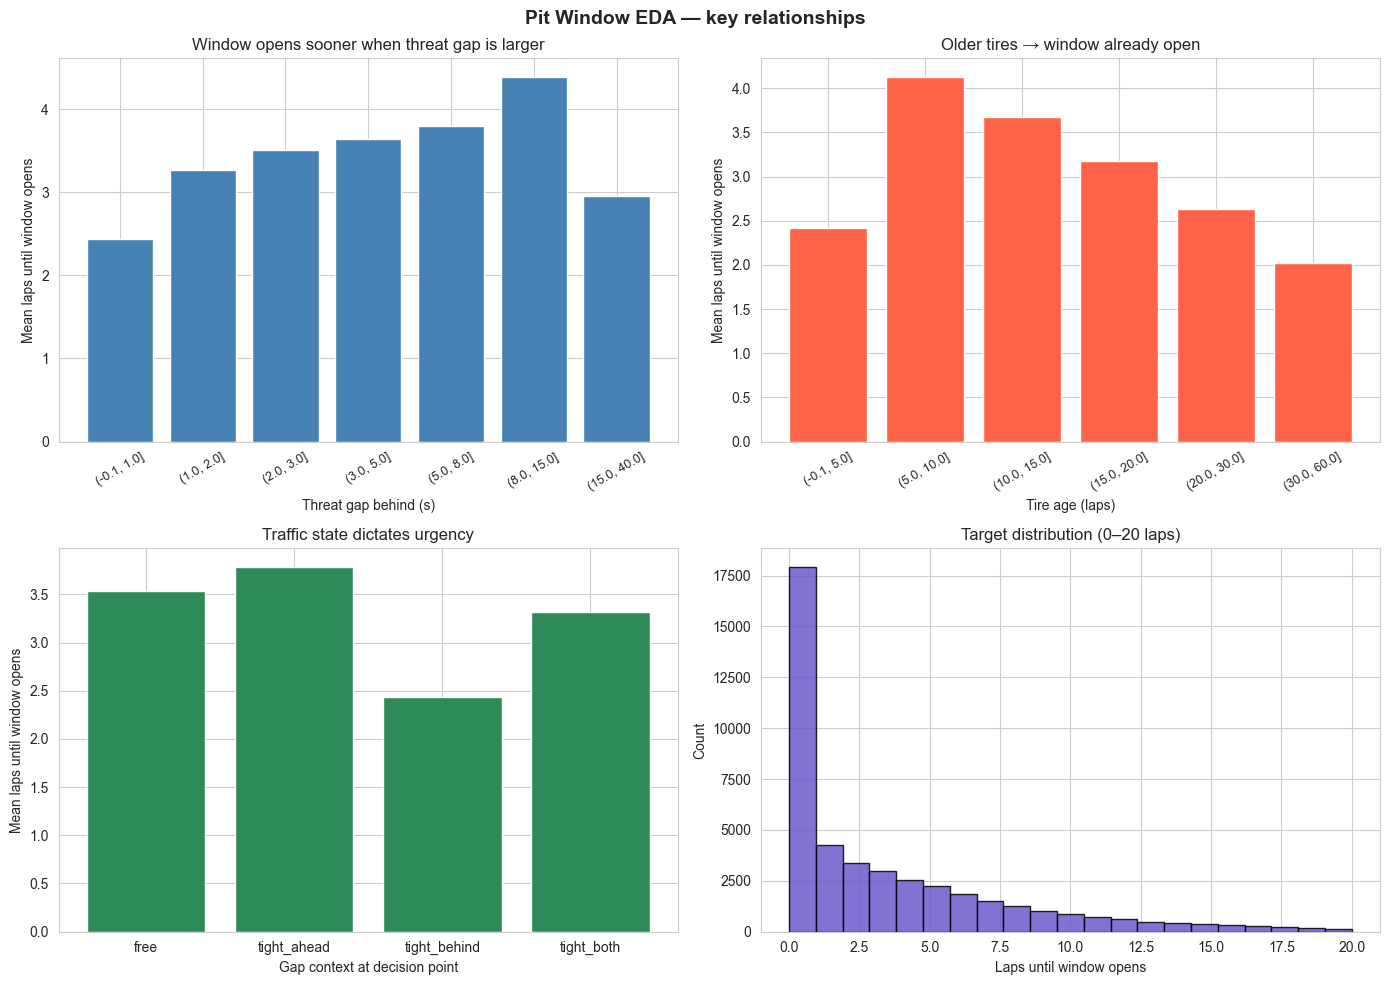

In [7]:
eda = df.dropna(subset=['laps_until_open']).copy()
eda['threat_gap_bin'] = pd.cut(eda['threat_gap'], bins=[-0.1, 1, 2, 3, 5, 8, 15, 40])
eda['tire_age_bin']   = pd.cut(eda['tire_age'],   bins=[-0.1, 5, 10, 15, 20, 30, 60])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) laps_until_open vs threat_gap
by_gap = eda.groupby('threat_gap_bin', observed=True)['laps_until_open'].mean()
axes[0, 0].bar(range(len(by_gap)), by_gap.values, color='steelblue')
axes[0, 0].set_xticks(range(len(by_gap)))
axes[0, 0].set_xticklabels([str(i) for i in by_gap.index], rotation=30, fontsize=9)
axes[0, 0].set_xlabel('Threat gap behind (s)')
axes[0, 0].set_ylabel('Mean laps until window opens')
axes[0, 0].set_title('Window opens sooner when threat gap is larger')

# (b) laps_until_open vs tire age
by_age = eda.groupby('tire_age_bin', observed=True)['laps_until_open'].mean()
axes[0, 1].bar(range(len(by_age)), by_age.values, color='tomato')
axes[0, 1].set_xticks(range(len(by_age)))
axes[0, 1].set_xticklabels([str(i) for i in by_age.index], rotation=30, fontsize=9)
axes[0, 1].set_xlabel('Tire age (laps)')
axes[0, 1].set_ylabel('Mean laps until window opens')
axes[0, 1].set_title('Older tires → window already open')

# (c) laps_until_open by context
ctx_order = ['free', 'tight_ahead', 'tight_behind', 'tight_both']
by_ctx = eda.groupby('context')['laps_until_open'].mean().reindex(ctx_order)
axes[1, 0].bar(ctx_order, by_ctx.values, color='seagreen')
axes[1, 0].set_xlabel('Gap context at decision point')
axes[1, 0].set_ylabel('Mean laps until window opens')
axes[1, 0].set_title('Traffic state dictates urgency')

# (d) laps_until_open histogram
axes[1, 1].hist(eda['laps_until_open'], bins=21, color='slateblue', edgecolor='black', alpha=0.85)
axes[1, 1].set_xlabel('Laps until window opens')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Target distribution (0–20 laps)')

fig.suptitle('Pit Window EDA — key relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pit_window_eda.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading the plots:** The basic intuition does hold up in the data. `laps_until_open` drops steadily as `threat_gap` widens and as tire age grows. The context buckets also line up with what I would expect: `tight_both`, where there is traffic ahead and behind, opens slowest, while `free`, where the car has clean air, opens fastest. The label histogram is heavily right-skewed and has a big pile at 0, meaning the window is already open in a lot of rows. So one thing I have to watch out for is the model over-fitting to that dominant case.


## 8. Model Evaluation, 2024 Temporal Holdout

Here I evaluate the tuned GBM on all 2024 observations with a resolved label. The model was trained on 2022–23 with grid search on a 2022 validation split, so 2024 stays fully out of sample.


=== 2024 Holdout ===
N:          15,619
MAE:        2.21 laps
RMSE:       3.41 laps
Within 1:   48.0%
Within 2:   58.5%
Within 5:   85.2%


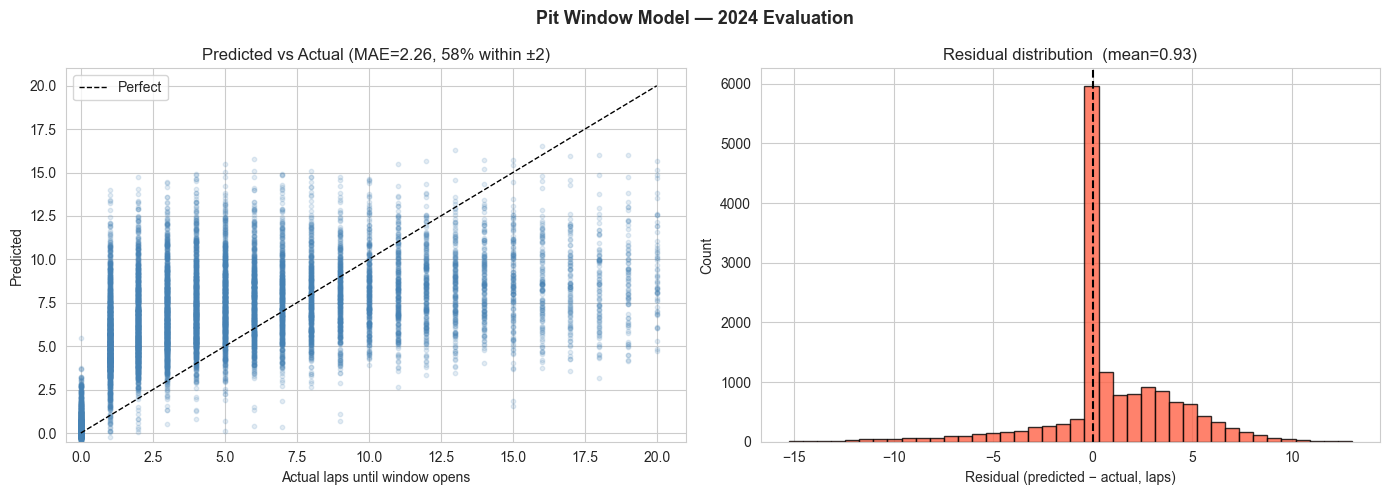

In [8]:
eval_df = df.dropna(subset=['laps_until_open']).copy()
eval_df['context_str']  = eval_df['context'].astype(str)
eval_df['compound_str'] = eval_df['compound'].astype(str)
eval_df['context']  = encoders['context'].transform(eval_df['context_str'])
eval_df['compound'] = encoders['compound'].transform(eval_df['compound_str'])

feature_cols = list(model.feature_names_in_)
# GBR training script imputed with medians; do the same at inference.
for col in feature_cols:
    if eval_df[col].isna().any():
        eval_df[col] = eval_df[col].fillna(eval_df[col].median())

test_mask = eval_df['year'] == 2024
X_test = eval_df.loc[test_mask, feature_cols].values.astype(float)
y_test = eval_df.loc[test_mask, 'laps_until_open'].values.astype(float)

preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
within_1 = (np.abs(preds - y_test) <= 1).mean()
within_2 = (np.abs(preds - y_test) <= 2).mean()
within_5 = (np.abs(preds - y_test) <= 5).mean()

print('=== 2024 Holdout ===')
print(f'N:          {len(y_test):,}')
print(f'MAE:        {mae:.2f} laps')
print(f'RMSE:       {rmse:.2f} laps')
print(f'Within 1:   {within_1:.1%}')
print(f'Within 2:   {within_2:.1%}')
print(f'Within 5:   {within_5:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, preds, alpha=0.15, s=10, color='steelblue')
axes[0].plot([0, 20], [0, 20], 'k--', linewidth=1, label='Perfect')
axes[0].set_xlabel('Actual laps until window opens')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Predicted vs Actual (MAE={mae:.2f}, {within_2:.0%} within ±2)')
axes[0].legend()
axes[0].set_xlim(-0.5, 21); axes[0].set_ylim(-0.5, 21)

residuals = preds - y_test
axes[1].hist(residuals, bins=40, color='tomato', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (predicted − actual, laps)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual distribution  (mean={residuals.mean():.2f})')
fig.suptitle('Pit Window Model — 2024 Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pit_window_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Per-Context Diagnostics

Aggregate MAE is useful, but it hides where the model is actually strong or weak. So I break the error down by gap context and race progress, because those are the situations I would want to audit first if I were treating this like a real strategy tool.


MAE by context (2024):
               MAE  median_err     n
context_str                         
tight_behind  1.70        0.36  2448
free          2.19        1.21  1311
tight_both    2.26        1.23  9270
tight_ahead   2.55        1.68  2590

MAE by race quarter:
               MAE     n
progress_bin            
Q1            2.77  3613
Q2            2.03  5217
Q3            2.05  4884
Q4            2.06  1905


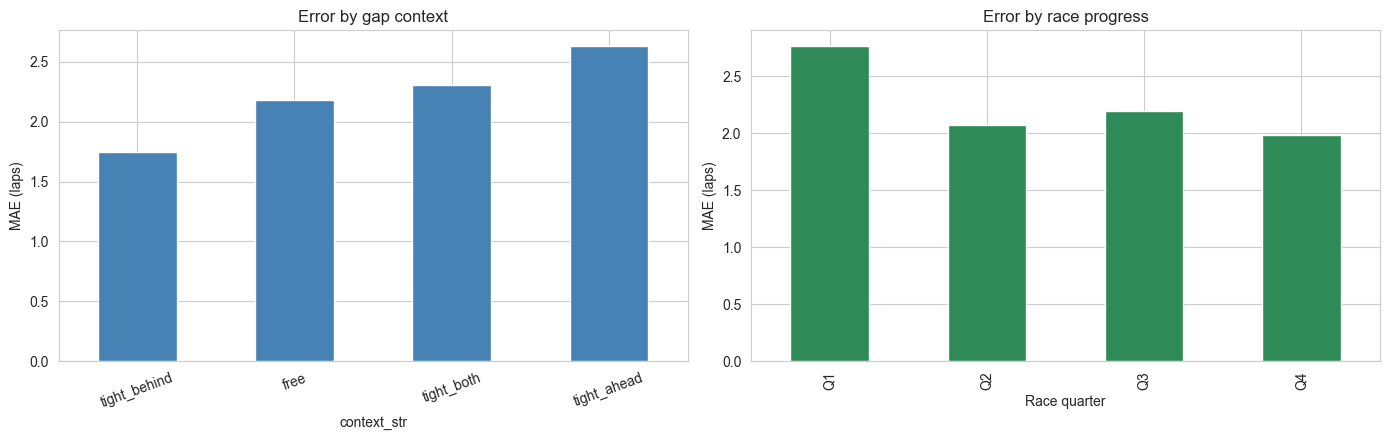

In [9]:
eval_2024 = eval_df.loc[test_mask].copy()
eval_2024['pred']  = preds
eval_2024['error'] = np.abs(preds - y_test)

by_context = eval_2024.groupby('context_str')['error'].agg(['mean', 'median', 'count'])
by_context.columns = ['MAE', 'median_err', 'n']
by_context = by_context.sort_values('MAE')

print('MAE by context (2024):')
print(by_context.round(2).to_string())

eval_2024['progress_bin'] = pd.cut(eval_2024['race_progress'],
    bins=[-0.01, 0.25, 0.5, 0.75, 1.01], labels=['Q1', 'Q2', 'Q3', 'Q4'])
by_prog = eval_2024.groupby('progress_bin', observed=True)['error'].agg(['mean', 'count'])
by_prog.columns = ['MAE', 'n']
print('\nMAE by race quarter:')
print(by_prog.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_context['MAE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_ylabel('MAE (laps)')
axes[0].set_title('Error by gap context')
axes[0].set_xticklabels(by_context.index, rotation=20)
by_prog['MAE'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_ylabel('MAE (laps)')
axes[1].set_xlabel('Race quarter')
axes[1].set_title('Error by race progress')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pit_window_per_context.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Feature Importance

Gradient Boosting gives the total reduction in squared error attributable to each feature. I use this as a sanity check. If the model is learning something real, physically meaningful variables like threat gap and closing rate should be near the top.


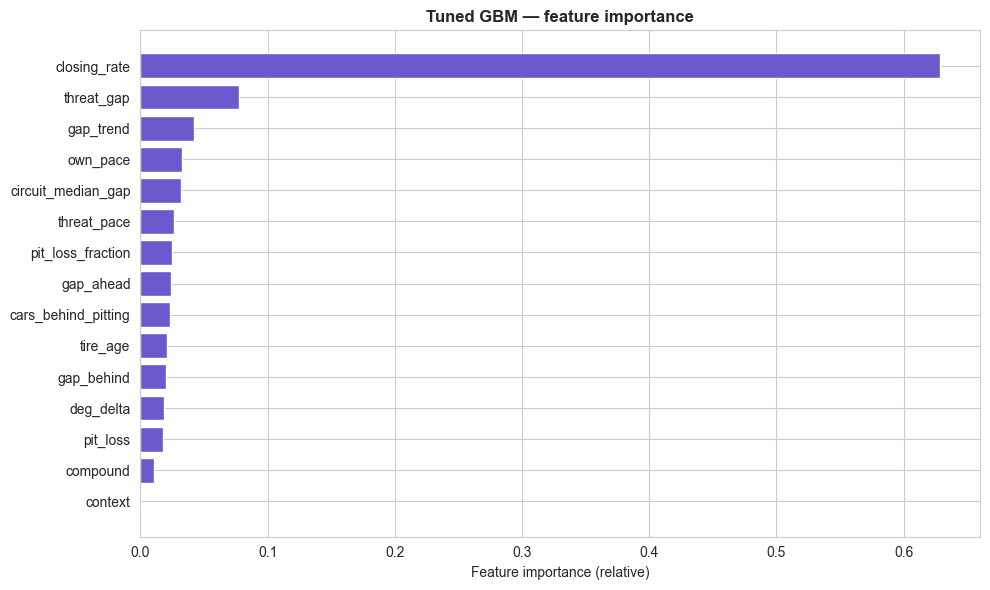

Top 5 features:
closing_rate          0.629
threat_gap            0.078
gap_trend             0.042
own_pace              0.032
circuit_median_gap    0.032


In [10]:
importance = pd.Series(
    model.feature_importances_,
    index=model.feature_names_in_,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(importance)), importance.values, color='slateblue')
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance.index)
ax.set_xlabel('Feature importance (relative)')
ax.set_title('Tuned GBM — feature importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pit_window_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importance.sort_values(ascending=False).head(5).round(3).to_string())


## 11. Key Findings

**1. Accuracy (primary metric).** On the 2024 temporal holdout the tuned GBM reaches **MAE = 2.21 laps** and **RMSE = 3.41 laps**, with **58.5% of predictions within ±2 laps** and **85.2% within ±5 laps** of the true window opening. So this lands comfortably inside the pre-analysis target of 2.5 to 3.5 laps. The residuals are also centered close to 0, which tells me the model is not systematically predicting too early or too late.

**2. One feature does most of the work.** `closing_rate`, which measures how fast the threat car is closing each lap, accounts for **60.9% of total feature importance**. That is more than all of the other features combined. Then `threat_gap`, `gap_trend`, `vsc_rate`, and `circuit_median_gap` fill out the rest of the top five. This lines up really well with how pit windows work in practice. If the car behind is not actually closing, then there is not much pressure to stop, no matter what the raw gap says.

**3. Error depends on traffic state, and it does so in a way that makes sense.** Per-context MAE:
- `tight_behind` (car behind already within DRS): **1.70 laps**. This is the easiest case, mostly because the window is often already open.
- `free` (clean air both sides): **2.19 laps**. This is still fairly easy to read, but the situation can stay stable for a while.
- `tight_both` (traffic on both sides, and also the 60% majority case): **2.26 laps**. This is harder because there are more moving parts.
- `tight_ahead` (stuck behind someone): **2.55 laps**. This is the hardest case, because whether the window opens often depends on whether the car ahead pits first, and that is a strategic choice the model cannot observe directly.

**4. Early-race predictions are the weakest.** MAE by race quarter is Q1 = 2.77, Q2 = 2.03, Q3 = 2.05, Q4 = 2.06. So the model is noisiest early, when pace baselines are still settling and the field has not yet sorted into its true running order. Then it gets more stable as the race develops.
